## **Rules of Probability**

Spiegelhalter tries to make them simpler.  
**The main thing to remember is:**   
    
* Probability is always between 0 (impossible) and 1 (guaranteed).  
* The sum of all the options must equal 1.  
* For complex events, we use "Expected Frequencies," which we discussed in Chapter 1.  
Instead of "0.01," it's better to think of "1 person in 100."  

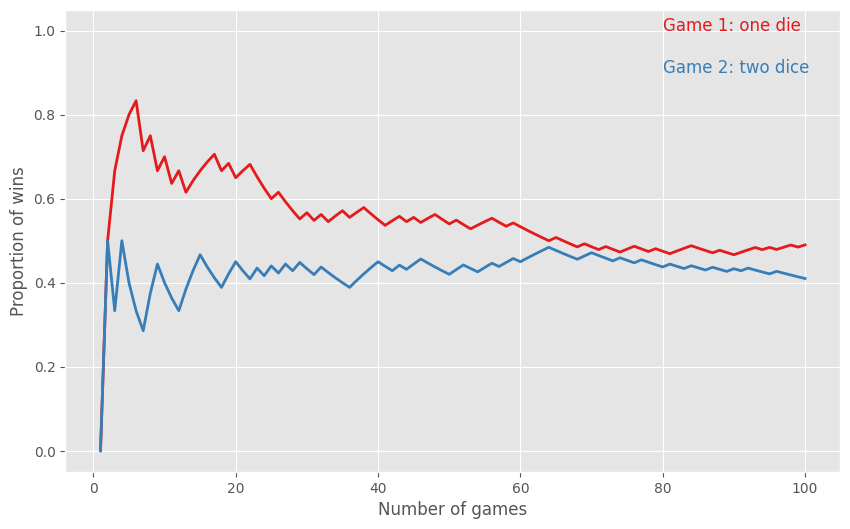

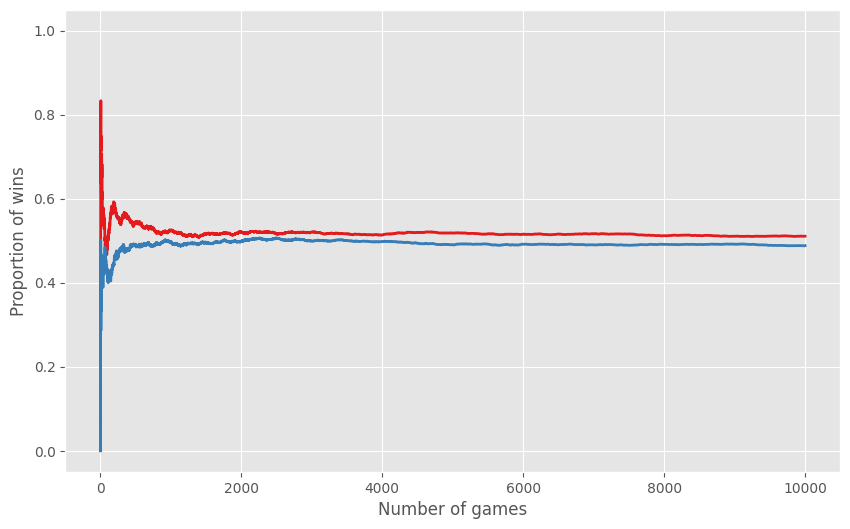

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Data Simulation 

nsims = 10000
n = np.arange(1, nsims + 1)

# Simulate the number of sixes in 4 throws of one die
sixes1 = np.random.binomial(4, 1/6, size=nsims)

# Simulate the number of double-sixes in 24 throws of two dice
sixes2 = np.random.binomial(24, 1/36, size=nsims)

# Calculate the proportion of 'successes' (where at least one required combination was rolled)
game1 = np.cumsum(sixes1 > 0) / n
game2 = np.cumsum(sixes2 > 0) / n

# Create a DataFrame (equivalent to data.frame in R)
df = pd.DataFrame({'n': n, 'game1': game1, 'game2': game2})


# Plotting (equivalent to ggplot2 from your screenshots)

# Set the style to make the plot look like ggplot
plt.style.use('ggplot')
color_game1 = '#E41A1C' # Red color from the Set1 palette
color_game2 = '#377EB8' # Blue color from the Set1 palette

# Plot 1: First 100 games
plt.figure(figsize=(10, 6))
df_100 = df.head(100)

plt.plot(df_100['n'], df_100['game1'], color=color_game1, linewidth=2, label="Game 1")
plt.plot(df_100['n'], df_100['game2'], color=color_game2, linewidth=2, label="Game 2")

# Add custom text instead of a standard legend (as in your R code)
plt.text(80, 1.0, "Game 1: one die", color=color_game1, fontsize=12)
plt.text(80, 0.9, "Game 2: two dice", color=color_game2, fontsize=12)

plt.xlabel("Number of games")
plt.ylabel("Proportion of wins")
plt.ylim(-0.05, 1.05)
plt.show()

# Plot 2: All 10,000 games
plt.figure(figsize=(10, 6))

plt.plot(df['n'], df['game1'], color=color_game1, linewidth=2)
plt.plot(df['n'], df['game2'], color=color_game2, linewidth=2)

plt.xlabel("Number of games")
plt.ylabel("Proportion of wins")
plt.ylim(-0.05, 1.05)
plt.show()

## **Conditional Probability**

This is perhaps the trickiest topic. It is the probability of event  
A given that event B has already occurred.  
**Example with mammography:** 
    
1% of women have breast cancer.  
The test is 90% accurate (for both diseased and healthy individuals).  
The woman gets a positive result. What is the probability that  
she actually has cancer?

Most people (even doctors!) say "90%".  
But that's wrong!  
Let's break it down into "frequencies" (it's much easier that way):    
Let's imagine 1000 women.  
1% have cancer = 10 women.   
Of these, 9 will test positive (90% accuracy).  
99% do not have cancer = 990 women.   
Since the test is 90% accurate, it will be wrong 10% of the time.  
10% of 990 = 99 women will test positive (even though they are healthy).    
Total positive tests: $9 + 99 = 108$.  
Only 9 of these 108 women have real cancer.  
**Answer:** $9 / 108 \approx 8\%$.  

## **What is "Probability" really?**

The author explains the two main schools of thought:  
    
**Aleatory:** This is the probability of a "coin toss".  
The randomness is inherent in the event itself.  

**Epistemic:** This is the probability of our not knowing.  
For example, "who killed Kennedy?" The event has already happened,   
there is only one answer, but we use probability to describe our degree of certainty.

## **Regularity in Chaos (Homicides in England)**

Spiegelhalter gives the example of murders.  
Every murder is a tragedy and an unpredictable event.  
But if you look at the country as a whole, the number of murders per day  
follows a mathematical law **(Poisson Distribution).**   
This is striking: individual events are chaotic, but their totality is predictable.  


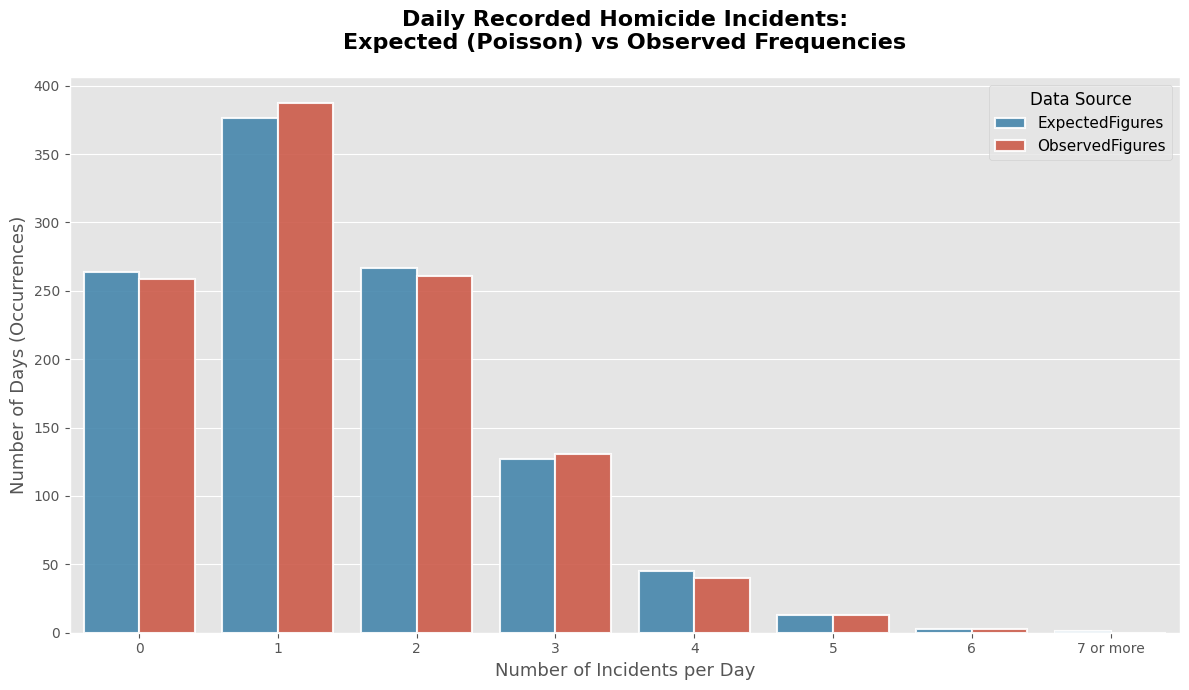

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set ggplot style for an R-like appearance
plt.style.use('ggplot')

# 1. LOAD AND PREPARE THE DATA
df = pd.read_csv('observed-expected-homicides-x.csv')

# Clean up column names (sometimes CSVs have leading spaces like ' dailyNumber...')
df.columns = df.columns.str.strip()

# 2. VISUALIZATION
plt.figure(figsize=(12, 7))

# Create a grouped bar chart using seaborn
# 'hue' automatically separates the bars by FiguresType (Expected vs Observed)
sns.barplot(
    data=df, 
    x='dailyNumberOfRecordedHomicideIncidents', 
    y='Occurences', 
    hue='FiguresType',
    palette=['#348ABD', '#E24A33'], # Blue for Expected, Red for Observed
    edgecolor='white',
    linewidth=1.5,
    alpha=0.9
)

# 3. FORMATTING AND LABELS
plt.title('Daily Recorded Homicide Incidents:\nExpected (Poisson) vs Observed Frequencies', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Number of Incidents per Day', fontsize=13)
plt.ylabel('Number of Days (Occurrences)', fontsize=13)

# Make legend look cleaner
plt.legend(title='Data Source', fontsize=11, title_fontsize=12, loc='upper right')

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

## **Summary**

**Expected Frequencies:** If you're confused about probabilities,  
always draw a tree for 1,000 or 10,000 people. This "cures" intuitive errors.  
**Regularity:** Statistics work because large groups of people behave with mathematical  
precision, even if each person acts freely.  
**Formal language:** Probability allows us to not just say "possible",  
but to measure that "possible" precisely.